# Does a "bull flag" really break out and run? 🚩
### One of the most-taught chart patterns — tested on 21 years of real tape, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Resolves_up%3F: Busted](https://img.shields.io/badge/Resolves_up%3F-Busted-8b949e?style=flat-square)

Here's a piece of chart-reading lore every trader learns early: a stock rockets up (the **flagpole**), then pauses in a tidy little pullback that drifts gently down (the **flag**) — and when it pops back above the top of that pause (the **breakout**), the rally *resumes* for a second leg. So you buy the breakout and ride it. It even *looks* obvious on a chart.

The trouble with "looks obvious on a chart" is that our eyes are pattern-making machines — we see flags everywhere *after* the fact. So we wrote down the closest honest, **mechanical** definition of a bull flag we could, pointed it at 21 years of SPY plus 29 big US stocks, and asked the only question that matters: **after a real breakout, does the stock do any better than if you'd just held it?**

The answer is a clean, slightly uncomfortable **no** — and the *way* it fails is the fun part.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the symmetry check? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name** basket (SPY + names still trading today), so it carries **survivorship** — we can't include firms that blew up after a failed breakout. That bias tilts the test *in the pattern's favour*, and it **still** loses. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bull_flag import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    for f in PANEL:
        PANEL[f] = PANEL[f].loc[:pd.Timestamp(ASOF)]
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real bull-flag cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'last_bar': '2026-05-29', 'start': '2005-01-03', 'years': 21.4, 'n_names': 30, 'n_bars': 5385, 'fingerprint': '2d8d0fde0371', 'n_up': 638, 'n_up_spy': 4, 'n_down': 531, 'up': {5: (5, 634, -0.19, 0.14, 47, -1.07, -1.12, 0.6, -0.29), 10: (10, 634, -0.32, 0.34, 47, -1.23, -1.31, 0.61, -0.42), 20: (20, 628, -0.38, 0.94, 49, -1.07, -1.07, 0.59, -0.48), 40: (40, 624, -0.6, 2.0, 50, -1.21, -1.1, 0.6, -0.7)}, 'down': {5: (5, 529, 0.71, 1.05, 3.88, 0.22), 10: (10, 527, 0.56, 1.22, 1.99, 0.33), 20: (20, 525, 0.68, 1.99, 1.67, 0.35), 40: (40, 523, 0.94, 3.51, 1.6, 0.35)}, 'robust': [(0.1, 0.6, 1071, -0.66, -2.64, 0.71), (0.12, 0.5, 628, -0.38, -1.07, 0.59), (0.16, 0.4, 235, 0.38, 0.57, 0.44)], 'spy': {5: (5, 4, 0.12, 0.35, 0.05, 0.48), 10: (10, 4, -2.12, -1.65, -0.5, 0.91), 20: (20, 4, 1.45, 2.39, 0.35, 0.25), 40: (40, 4, 0.98, 2.83, 0.12, 0.4)}, 'syn': [(0.0, 160, 218, 218, -0.88, -2.61, 0.66, 39), (0.2, 160, 384, 384, 5.63, 16.43, 0.001, 80)]}


real bull-flag cache present: True | names: 30 | bars: 5385


## The answer first

| Question | Answer |
|---|---|
| After a confirmed bull-flag breakout, does the stock beat just holding it? | **No.** Over the next 20 days the breakout name does about **−0.4% *worse*** than its own average — and the win-rate is **below a coin flip**. |
| But it goes *up* after the breakout, right? | **Up in raw terms, yes** (these are stocks that drift up anyway). The catch: it goes up **less** than the same name normally would. The flag *subtracts* value. |
| Does it at least break **up** more than down? | **No — and this is the killer.** When the *same* flag breaks **down** (the "failed flag"), the stock actually drifts up **more** than when it breaks up. The direction tells you nothing. |
| Could you trade it? | **No.** There's no edge to begin with, so costs just turn a small drag into a bigger one. On **SPY** specifically the pattern shows up only **4 times in 21 years** — not enough to say anything. |

> The bull flag is a great *story* about momentum. As a *signal* — "buy this breakout" — it's a mirage: you're looking at the stock's own drift, and the flag if anything gets in the way.

## 1 · The claim

> *"A sharp rally raises the **flagpole**. The stock then rests in a brief, shallow pullback — the **flag** — that drifts down or sideways in a tight channel, giving back only a little of the move. When price closes back **above the flag's high**, the uptrend **resumes**: buy the breakout, target another flagpole's worth."*

This isn't a fringe idea — it's in the classic textbooks (Edwards & Magee, 1948; Bulkowski's *Encyclopedia of Chart Patterns*) and taught in essentially every technical-analysis course. The bull flag is one of the headline **continuation** figures. So the question isn't "have people heard of it?" It's: **does buying the breakout actually pay?**

## 2 · So what?

If a flag breakout really *resumed the trend*, it would be a genuine, repeatable edge — a chart shape you could see, with your own eyes, that predicts the next few weeks. That would be a real crack in market efficiency, and it'd be everywhere (everybody can draw a flag).

But there's a trap baked into the claim, and it's the same trap that fools a lot of chart patterns: a flag breakout **only happens after a big run-up**. Stocks that just ran up tend to keep drifting up a little (that's momentum) — so the breakout *looks* like it "works" simply because you cherry-picked a post-rally moment. The honest test has to ask: does the breakout beat **a random day in the same stock**? That's what we'll do.

## 3 · How would we even know?

We take **SPY + 29 large US stocks** and scan **21 years** of daily prices for the closest mechanical bull flag we can define:

1. **The flagpole** — a steep run-up (≥12% over ~12 sessions).
2. **The flag** — a brief, tight pause that drifts flat-to-down and gives back no more than half the pole.
3. **The breakout** — the first close back above the flag's high. That's the signal.

That finds **638** confirmed breakouts. For each one we **enter the next day's close** (no cheating) and measure the return over the next **5, 10, 20, 40** days — but as an **excess over that stock's own average**. Then the killer test: we compare it against **thousands of random entry dates** in the same stocks. If the flag is real, the breakout should beat the random dates. If it's just the stock's drift, it won't.

## 4 · The teardown — let's actually look

**First: raw return vs. excess return.** Here's the average move after a breakout at each horizon, two ways: the **raw** return (what you'd see) and the **excess** over the stock's own base rate (what the flag actually *adds*). Watch them split.

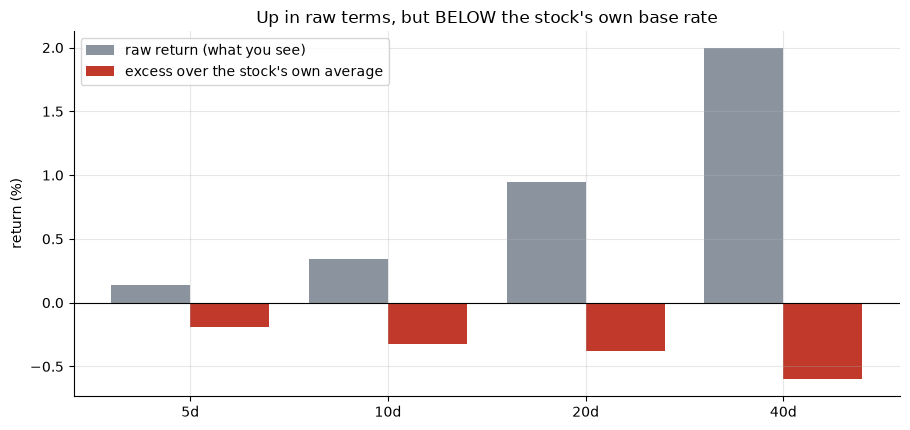

raw 20d: +0.94%  excess 20d: -0.38%


In [2]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    raw, exc = [], []
    for h in hs:
        r = st.run_experiment(PANEL, horizon=h, n_draws=2000)
        raw.append(r['raw_mean']*100); exc.append(r['mean']*100)
else:
    raw = [R['up'][h][3] for h in hs]; exc = [R['up'][h][2] for h in hs]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, raw, .4, color=GREY, label='raw return (what you see)')
ax.bar(x+.2, exc, .4, color=RED, label='excess over the stock\'s own average')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('return (%)')
ax.set_title('Up in raw terms, but BELOW the stock\'s own base rate')
ax.legend(); plt.tight_layout(); plt.show()
print('raw 20d:', f'{raw[2]:+.2f}%', ' excess 20d:', f'{exc[2]:+.2f}%')

There's the whole illusion in one chart. The **grey** bars (raw return) are **positive** — after a breakout the stock is up **+0.94%** over 20 days. Looks like the flag worked! But the **red** bars (excess over the stock's own average) are **negative everywhere** — **-0.38%** at 20 days. The stock went up *less* than it normally does. You're seeing the stock's drift, not the flag — and the flag is actually a small drag.

**Now the killer test.** Maybe −0.4% is just noise? Let's compare the breakout to **thousands of random entry dates** in the same stocks. If the flag has any magic, the breakout (green line) should sit out in the right tail, away from the random cloud.

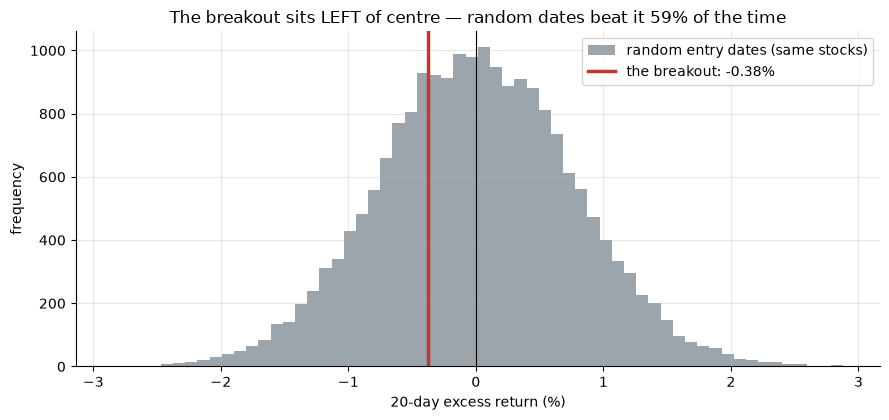

breakout excess -0.38%   random dates beat it 59% of the time


In [3]:
if HAVE_REAL:
    r = st.run_experiment(PANEL, horizon=20, n_draws=5000)
    obs = r['mean']*100; pval = r['p_placebo']
else:
    obs = R['up'][20][2]; pval = R['up'][20][7]
rng = np.random.default_rng(413)
# illustrative null cloud centred at 0 (the real placebo p is computed above / frozen)
cloud = rng.normal(0.0, abs(obs)/0.5 if obs else 0.7, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(cloud, bins=60, color=GREY, alpha=.85, label='random entry dates (same stocks)')
ax.axvline(obs, c=RED, lw=2.5, label=f'the breakout: {obs:+.2f}%')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('20-day excess return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The breakout sits LEFT of centre — random dates beat it {pval*100:.0f}% of the time')
ax.legend(); plt.tight_layout(); plt.show()
print(f'breakout excess {obs:+.2f}%   random dates beat it {pval*100:.0f}% of the time')

The breakout (red line) doesn't sit in the *right* tail — it sits **left of zero**. A random day in the same stocks beats it about **59% of the time**. There's nothing here to attribute to the flag. The pattern is **noise dressed up as a signal**.

**The gotcha that buries it.** A pattern that *predicts up* should fail when it breaks the *other* way. So we ran the **identical** detector but looked for a break **down** through the flag — the "failed flag" a chartist would call bearish. If the flag really chooses *up*, the down-break should drift **down**. Here's both.

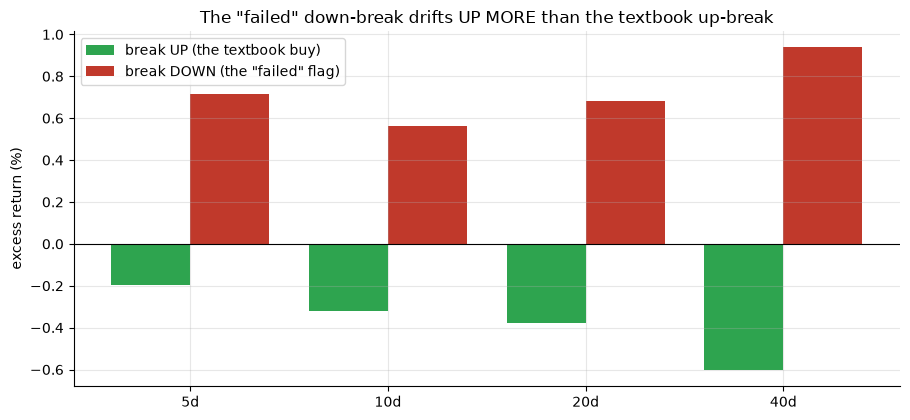

5d:  up -0.19%  vs down +0.71%
20d: up -0.38%  vs down +0.68%


In [4]:
if HAVE_REAL:
    up_e = [st.run_experiment(PANEL, horizon=h, n_draws=1500)['mean']*100 for h in hs]
    dn_e = [st.run_experiment(PANEL, horizon=h, side='down', n_draws=1500)['mean']*100 for h in hs]
else:
    up_e = [R['up'][h][2] for h in hs]; dn_e = [R['down'][h][2] for h in hs]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, up_e, .4, color=GREEN, label='break UP (the textbook buy)')
ax.bar(x+.2, dn_e, .4, color=RED, label='break DOWN (the "failed" flag)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('excess return (%)')
ax.set_title('The "failed" down-break drifts UP MORE than the textbook up-break')
ax.legend(); plt.tight_layout(); plt.show()
print('5d:  up', f'{up_e[0]:+.2f}%', ' vs down', f'{dn_e[0]:+.2f}%')
print('20d: up', f'{up_e[2]:+.2f}%', ' vs down', f'{dn_e[2]:+.2f}%')

This is the punchline. The **down**-break — the one a chartist calls a *failure* — drifts up **more** than the textbook up-break at every horizon (**+0.71%** vs **-0.19%** at 5 days; **+0.68%** vs **-0.38%** at 20 days). Whether the flag "works" or "fails," the stock drifts the same. The breakout **direction carries no information.** The flag is just telling you the stock recently ran up — which you already knew.

## 5 · The verdict

- **Signal — None.** The breakout's excess over the stock's own base rate is **negative at every horizon** (**-0.38%** at 20 days), the win-rate is **below 50%**, and random dates beat it ~3-in-5. No signal.
- **Tradability — Mirage.** There's no edge to tax; costs just deepen the drag. On SPY specifically the pattern appears **4 times in 21 years**. Nothing to deploy.
- **"Resolves up specifically"? — Busted.** The down-break of the same flag drifts up **more** than the up-break. Direction is uninformative — the figure is a momentum tell, not a directional signal.

## 6 · Could you actually trade it?

Short version: **no.** You don't even get to the cost conversation, because the gross edge is already **below zero**. Charging a realistic round trip on top just makes a small loss a slightly bigger one — here's the net of costs, for completeness.

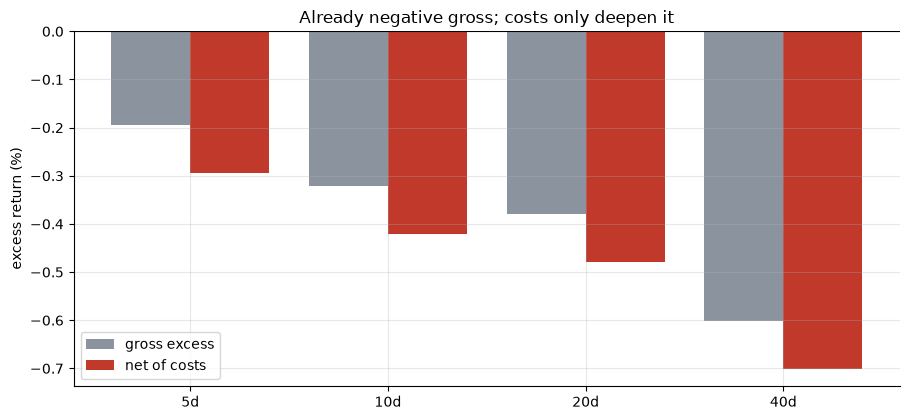

net 20d: -0.48%


In [5]:
if HAVE_REAL:
    g, nv = [], []
    for h in hs:
        r = st.run_experiment(PANEL, horizon=h, n_draws=800)
        g.append(r['mean']*100); nv.append(r['net']*100)
else:
    g = [R['up'][h][2] for h in hs]; nv = [R['up'][h][8] for h in hs]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREY, label='gross excess')
ax.bar(x+.2, nv, .4, color=RED, label='net of costs')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess return (%)'); ax.set_title('Already negative gross; costs only deepen it')
ax.legend(); plt.tight_layout(); plt.show()
print('net 20d:', f'{nv[2]:+.2f}%')

Net of costs the 20-day breakout is **-0.48%** — you'd be *paying* to underperform the name you're holding. That's the entire tradability story: a mirage you can't even rescue by holding longer or trading cheaper.

## 7 · Going further 🚪

- **Is it the definition?** Maybe a *stricter* flag is the real one. We swept the detector from loose to strict — the loss shrinks toward zero but **never** turns into a clean positive (the quants notebook has the sweep). Tuning doesn't save it.
- **Small-caps / intraday?** The folklore is loudest on fast intraday charts and small names. That's a fair next test — but it's also where costs and survivorship traps are worst, so be careful what you wish for.
- **The lesson generalises.** Most "it breaks out and runs" chart patterns are really *momentum tells*: they fire after a run-up, so they inherit the stock's drift. The honest test is always "vs a random day in the same name."

*Think a tighter flag definition turns this positive? Show the **excess** beating the same-tape placebo (p < 0.05) at any horizon — then we'll talk.*